In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True) # mounting my colab notebook onto my google drive contents

Mounted at /content/drive


In [4]:
import pandas as pd

In [2]:
!pip install great_tables
!pip install selenium
!pip install -U kaleido
from great_tables import GT

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.2/607.2 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.3/510.3 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 10.0 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.6 MB/s eta 0:00:00


In [4]:
!pip install -q -U yellowbrick
!pip install -q umap-learn
!pip install -q transformers
!pip install -q shap
!pip install -q datasets
!pip install -q sentence-transformers
!pip install -q hdbscan
!pip install -q bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 8.9 MB/s eta 0:00:00


In [5]:
from bertopic import BERTopic
from hdbscan import HDBSCAN
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, date, timedelta
import pandas as pd
import numpy as np
import random
from transformers import AutoModelForSequenceClassification
#from transformers import TFAutoModelForSequenceClassification: this line is
#commented out because of some import/version issue on google colab
from transformers import AutoTokenizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
import torch
import tensorflow.keras as tf_keras
from umap import UMAP
from sentence_transformers import SentenceTransformer
from nltk.corpus import stopwords

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [6]:
# navigating to my database in colab
import sqlite3
conn = sqlite3.connect('/content/drive/MyDrive/tiktok_breadth_first.db')
cursor = conn.cursor()

In [7]:
# checking to see that the database exists.
# this is vital because sometimes i fail to realize which google account
# i'm using on colab ...

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print("Tables in the database:")
for table in tables:
    print(table[0])

Tables in the database:
users
follow_relations
videos


In [8]:
# getting kamala text

query = """
SELECT id, video_description, hashtag_names
FROM videos
JOIN follow_relations
ON videos.reposter_username = follow_relations.from_username
WHERE follow_relations.to_username = 'kamalahq'
"""

kamalahq_text = pd.read_sql(query, conn)
kamalahq_text = kamalahq_text.dropna()
kamalahq_text = kamalahq_text[kamalahq_text['video_description'] != '']

In [9]:
query = """
SELECT id, video_description, hashtag_names
FROM videos
JOIN follow_relations
ON videos.reposter_username = follow_relations.from_username
WHERE follow_relations.to_username = 'teamtrump'
"""

teamtrump_text = pd.read_sql(query, conn)
teamtrump_text = teamtrump_text.dropna()
teamtrump_text = teamtrump_text[teamtrump_text['video_description'] != '']

In [10]:
seed = 42
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)

In [15]:
import nltk
nltk.download('stopwords')
stopwords_list = list(stopwords.words('english')) + ['http', 'https', 'amp', 'com', 'co', 'fyp', 'viral', 'foryoupage', 'edit', 'foryou', 'funny', 'fypシ', 'relatable', 'trending', '', 'fypage', 'xyzbca', 'tiktok']
vectorizer_model = CountVectorizer(ngram_range=(1, 2), stop_words=stopwords_list)
embedding_model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2', device='cuda')
umap_model = UMAP(n_neighbors=5, n_components=3, metric='euclidean')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [66]:
k_cv_dict = {'Num Topics': [],
             'Min Cluster Size': [],
             'Silhouette Score': [],
             'Estimator': [],
             'Avg Topic Cosine Similarity': []
             }
t_cv_dict = {'Num Topics': [],
             'Min Cluster Size': [],
             'Silhouette Score': [],
             'Estimator': [],
             'Avg Topic Cosine Similarity': []
             }

In [67]:
sizes = list(range(25, 75))

In [68]:
for index, size in enumerate(sizes):
    # set seed
    random.seed(index)
    # sample bootstrap
    k_docs = random.sample(kamalahq_text['video_description'].to_list(), 10000)
    train_docs, test_docs = k_docs[:8000], k_docs[8000:]
    # define model
    kamalahq_topic = BERTopic(
      umap_model=umap_model,
      hdbscan_model=HDBSCAN(min_cluster_size=size,
                        gen_min_span_tree=True,
                        prediction_data=True,),
      embedding_model=embedding_model,
      vectorizer_model=vectorizer_model,
      top_n_words=5,
      language='multilingual',
      calculate_probabilities=True,
      verbose=True,
      )
    # fit and transform toipc model
    k_topics, k_probs = kamalahq_topic.fit_transform(train_docs)

    # score test documents
    test_embeddings = embedding_model.encode(test_docs)
    test_umap_embeddings = kamalahq_topic.umap_model.transform(test_embeddings)
    test_topics, test_probs = kamalahq_topic.transform(test_docs)
    indices = [index for index, topic in enumerate(test_topics) if topic != -1]
    X = test_umap_embeddings[np.array(indices)]
    labels = [topic for index, topic in enumerate(test_topics) if topic != -1]

    # Calculate silhouette score
    sil_score = silhouette_score(X, labels)

    kamalahq_embeddings = kamalahq_topic.topic_embeddings_

    # calculate pairwise cosine similarity
    avg_cosine_similarity_kamala = []
    for i in range(len(kamalahq_embeddings)):
        for j in kamalahq_embeddings[i:]:
            avg_cosine_similarity_kamala.append(cosine_similarity(\
                kamalahq_embeddings[i].reshape(1, -1), j.reshape(1, -1))[0][0])

    # update dictionary
    k_cv_dict['Num Topics'].append(len(kamalahq_topic.get_topic_info()))
    k_cv_dict['Min Cluster Size'].append(size)
    k_cv_dict['Silhouette Score'].append(sil_score)
    k_cv_dict['Estimator'].append(kamalahq_topic)
    k_cv_dict['Avg Topic Cosine Similarity'].append(np.mean(avg_cosine_similarity_kamala))

2026-03-29 18:12:10,165 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/250 [00:00<?, ?it/s]

2026-03-29 18:12:13,574 - BERTopic - Embedding - Completed ✓
2026-03-29 18:12:13,575 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-29 18:12:16,511 - BERTopic - Dimensionality - Completed ✓
2026-03-29 18:12:16,512 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-29 18:12:17,992 - BERTopic - Cluster - Completed ✓
2026-03-29 18:12:17,997 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-29 18:12:18,658 - BERTopic - Representation - Completed ✓


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

2026-03-29 18:12:22,226 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-03-29 18:12:22,522 - BERTopic - Dimensionality - Completed ✓
2026-03-29 18:12:22,522 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-03-29 18:12:22,627 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2026-03-29 18:12:23,176 - BERTopic - Probabilities - Completed ✓
2026-03-29 18:12:23,177 - BERTopic - Cluster - Completed ✓
2026-03-29 18:12:23,754 - BERTopic - Embedding - Transforming documents to embeddings.


...

2026-03-29 18:21:32,874 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-03-29 18:21:33,158 - BERTopic - Dimensionality - Completed ✓
2026-03-29 18:21:33,159 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-03-29 18:21:33,304 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2026-03-29 18:21:33,620 - BERTopic - Probabilities - Completed ✓
2026-03-29 18:21:33,621 - BERTopic - Cluster - Completed ✓
2026-03-29 18:21:33,790 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/250 [00:00<?, ?it/s]

2026-03-29 18:21:37,163 - BERTopic - Embedding - Completed ✓
2026-03-29 18:21:37,164 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-29 18:21:38,911 - BERTopic - Dimensionality - Completed ✓
2026-03-29 18:21:38,912 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-29 18:21:39,554 - BERTopic - Cluster - Completed ✓
2026-03-29 18:21:39,560 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-29 18:21:40,209 - BERTopic - Representation - Completed ✓


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

2026-03-29 18:21:43,622 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-03-29 18:21:43,928 - BERTopic - Dimensionality - Completed ✓
2026-03-29 18:21:43,929 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-03-29 18:21:44,074 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2026-03-29 18:21:44,387 - BERTopic - Probabilities - Completed ✓
2026-03-29 18:21:44,388 - BERTopic - Cluster - Completed ✓


In [69]:
k_cv_dict

{'Num Topics': [49,
  43,
  39,
  6,
  3,
  34,
  33,
  3,
  33,
  24,
  5,
  2,
  20,
  3,
  5,
  4,
  3,
  3,
  4,
  5,
  4,
  9,
  3,
  29,
  18,
  3,
  3,
  19,
  10,
  22,
  3,
  19,
  12,
  3,
  16,
  12,
  12,
  3,
  3,
  13,
  3,
  3,
  3,
  14,
  12,
  3,
  10,
  3,
  9,
  3],
 'Min Cluster Size': [25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74],
 'Silhouette Score': [np.float32(0.54416156),
  np.float32(0.5625154),
  np.float32(0.5405238),
  np.float32(0.07107661),
  np.float32(0.5936156),
  np.float32(0.5649267),
  np.float32(0.6138828),
  np.float32(0.711047),
  np.float32(0.5462055),
  np.float32(0.55468506),
  np.float32(0.4208577),
  np.float32(0.82437855),
  np.float32(0.19562453),
  np.float32(0.39707482),
  np.float32(0.27

In [70]:
k_models = k_cv_dict.pop('Estimator')

In [71]:
k_cv_df = pd.DataFrame(k_cv_dict)
k_cv_df.to_csv('drive/MyDrive/kamalahq_topic_model.csv')

In [72]:
for index, size in enumerate(sizes):
    # set seed
    random.seed(index)
    # sample bootstrap
    t_docs = random.sample(teamtrump_text['video_description'].to_list(), 10000)
    train_docs, test_docs = t_docs[:8000], t_docs[8000:]
    # define model
    teamtrump_topic = BERTopic(
      umap_model=umap_model,
      hdbscan_model=HDBSCAN(min_cluster_size=size,
                        gen_min_span_tree=True,
                        prediction_data=True,),
      embedding_model=embedding_model,
      vectorizer_model=vectorizer_model,
      top_n_words=5,
      language='multilingual',
      calculate_probabilities=True,
      verbose=True,
      )
    # fit and transform toipc model
    t_topics, t_probs = teamtrump_topic.fit_transform(train_docs)

    # score test documents
    test_embeddings = embedding_model.encode(test_docs)
    test_umap_embeddings = kamalahq_topic.umap_model.transform(test_embeddings)
    test_topics, test_probs = teamtrump_topic.transform(test_docs)
    indices = [index for index, topic in enumerate(test_topics) if topic != -1]
    X = test_umap_embeddings[np.array(indices)]
    labels = [topic for index, topic in enumerate(test_topics) if topic != -1]

    # Calculate silhouette score
    sil_score = silhouette_score(X, labels)

    teamtrump_embeddings = teamtrump_topic.topic_embeddings_

    # calculate pairwise cosine similarity
    avg_cosine_similarity_trump = []
    for i in range(len(teamtrump_embeddings)):
        for j in teamtrump_embeddings[i:]:
            avg_cosine_similarity_trump.append(cosine_similarity(\
                teamtrump_embeddings[i].reshape(1, -1), j.reshape(1, -1))[0][0])

    # update dictionary
    t_cv_dict['Num Topics'].append(len(teamtrump_topic.get_topic_info()))
    t_cv_dict['Min Cluster Size'].append(size)
    t_cv_dict['Silhouette Score'].append(sil_score)
    t_cv_dict['Estimator'].append(teamtrump_topic)
    t_cv_dict['Avg Topic Cosine Similarity'].append(np.mean(avg_cosine_similarity_trump))

2026-03-29 18:21:44,602 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/250 [00:00<?, ?it/s]

2026-03-29 18:21:47,958 - BERTopic - Embedding - Completed ✓
2026-03-29 18:21:47,959 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-29 18:21:49,703 - BERTopic - Dimensionality - Completed ✓
2026-03-29 18:21:49,704 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-29 18:21:50,813 - BERTopic - Cluster - Completed ✓
2026-03-29 18:21:50,819 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-29 18:21:51,470 - BERTopic - Representation - Completed ✓


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

2026-03-29 18:21:54,931 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-03-29 18:21:55,211 - BERTopic - Dimensionality - Completed ✓
2026-03-29 18:21:55,212 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-03-29 18:21:55,312 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2026-03-29 18:21:55,786 - BERTopic - Probabilities - Completed ✓
2026-03-29 18:21:55,787 - BERTopic - Cluster - Completed ✓
2026-03-29 18:21:56,145 - BERTopic - Embedding - Transforming documents to embeddings.


...

2026-03-29 18:30:46,824 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-03-29 18:30:47,101 - BERTopic - Dimensionality - Completed ✓
2026-03-29 18:30:47,102 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-03-29 18:30:47,248 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2026-03-29 18:30:47,552 - BERTopic - Probabilities - Completed ✓
2026-03-29 18:30:47,553 - BERTopic - Cluster - Completed ✓
2026-03-29 18:30:47,678 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/250 [00:00<?, ?it/s]

2026-03-29 18:30:50,926 - BERTopic - Embedding - Completed ✓
2026-03-29 18:30:50,927 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-29 18:30:52,752 - BERTopic - Dimensionality - Completed ✓
2026-03-29 18:30:52,753 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-29 18:30:53,418 - BERTopic - Cluster - Completed ✓
2026-03-29 18:30:53,422 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-29 18:30:54,022 - BERTopic - Representation - Completed ✓


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

2026-03-29 18:30:57,321 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-03-29 18:30:57,621 - BERTopic - Dimensionality - Completed ✓
2026-03-29 18:30:57,622 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-03-29 18:30:57,770 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2026-03-29 18:30:58,090 - BERTopic - Probabilities - Completed ✓
2026-03-29 18:30:58,091 - BERTopic - Cluster - Completed ✓


In [73]:
t_models = t_cv_dict.pop('Estimator')

In [74]:
t_cv_dict

{'Num Topics': [35,
  5,
  43,
  39,
  4,
  8,
  26,
  36,
  4,
  5,
  3,
  35,
  28,
  22,
  7,
  32,
  4,
  19,
  22,
  3,
  7,
  24,
  3,
  4,
  14,
  3,
  3,
  3,
  3,
  5,
  18,
  23,
  10,
  3,
  3,
  3,
  3,
  7,
  3,
  3,
  3,
  8,
  5,
  3,
  4,
  3,
  6,
  3,
  3,
  5],
 'Min Cluster Size': [25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74],
 'Silhouette Score': [np.float32(0.19035025),
  np.float32(0.4182689),
  np.float32(0.59064627),
  np.float32(0.537161),
  np.float32(0.4508209),
  np.float32(0.06703285),
  np.float32(0.45643353),
  np.float32(0.5699315),
  np.float32(0.27082556),
  np.float32(0.12061517),
  np.float32(0.68838894),
  np.float32(0.6340083),
  np.float32(0.52048844),
  np.float32(0.45645538),
  np.float32(0.26891

In [75]:
t_cv_df = pd.DataFrame(t_cv_dict)
t_cv_df.to_csv('drive/MyDrive/teamtrump_topic_model.csv')

In [76]:
# model selection

k_slice = k_cv_df[(k_cv_df['Num Topics'] >= 15) & (k_cv_df['Num Topics'] <= 30)].sort_values(by='Silhouette Score', ascending=False).reset_index()
t_slice = t_cv_df[(t_cv_df['Num Topics'] >= 15) & (t_cv_df['Num Topics'] <= 30)].sort_values(by='Silhouette Score', ascending=False).reset_index()


In [80]:
k_index = int(k_slice.loc[0, 'Min Cluster Size']) - 25
kamalahq_topic = k_models[k_index]
t_index = int(t_slice.loc[0, 'Min Cluster Size']) - 25
teamtrump_topic = t_models[t_index]

In [81]:
k_topic_info = kamalahq_topic.get_topic_info()
k_topic_info.head()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,4001,-1_papa papa_papa_like_love,"[papa papa, papa, like, love, one]","[#real , #real , Happy 15 Anniversary to Danga..."
1,0,491,0_fypシviral_fypシviral fypシviral_real_blowthisup,"[fypシviral, fypシviral fypシviral, real, blowthi...",[when the build up of saliva kicks in you know...
2,1,325,1_ceviche_need ceviche_ceviche need_need,"[ceviche, need ceviche, ceviche need, need, de]","[Back From Hiatus: Big Oysters, Wild Grouper &..."
3,2,284,2_video_comedy_jokes_joke,"[video, comedy, jokes, joke, funniest]",[I have never related so much to someone in my...
4,3,240,3_ad_roblox_fypp_parati,"[ad, roblox, fypp, parati, floptok]",[#hawk #hawkfrost #ivy #ivypool #warriors #cat...


In [29]:
# visualize

In [82]:
kamalahq_topic.visualize_topics()

In [83]:
kamalahq_topic.visualize_hierarchy()

In [84]:
kamalahq_topic.visualize_heatmap()

In [85]:
kamalahq_topic.visualize_barchart(top_n_topics=8, title= 'Kamala Harris BERTopic Topic Word Scores')

In [86]:
t_topic_info = teamtrump_topic.get_topic_info()
t_topic_info.head()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,4106,-1_real_de_la_fy,"[real, de, la, fy, meme]",[🇩🇪 La Germania si è tolta dal progetto che av...
1,0,564,0_viralvideo_blowthisup_capcut_fy,"[viralvideo, blowthisup, capcut, fy, real]",[#CapCut #Trending #viralvideo #viralvideo #fo...
2,1,379,1_fnaf_capcut_ib_bankai,"[fnaf, capcut, ib, bankai, korn]",[Jynxzi king repost🙏🙏#real #fyp #fyppp #relata...
3,2,339,2_football_footballtiktok_ronaldo_barcelona,"[football, footballtiktok, ronaldo, barcelona,...",[Football 🤍 #respect #viral #foryoupage #footb...
4,3,335,3_de_que_la_sante,"[de, que, la, sante, un]",[La plupart des gens se présentent mal (et ça ...


In [87]:
teamtrump_topic.visualize_hierarchy()

In [156]:
teamtrump_topic.visualize_barchart(top_n_topics=8, title = 'Donald Trump BERTopic Topic Word Scores')

In [144]:
teamtrump_topic.visualize_heatmap()

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

In [93]:
k_cv_df['candidate'] = ['kamalahq'] * len(k_cv_df)
t_cv_df['candidate'] = ['teamtrump'] * len(t_cv_df)

In [94]:
df = pd.concat([k_cv_df, t_cv_df])

In [95]:
df.head()

,Num Topics,Min Cluster Size,Silhouette Score,Avg Topic Cosine Similarity,candidate
0,49,25,0.544162,0.595244,kamalahq
1,43,26,0.562515,0.600765,kamalahq
2,39,27,0.540524,0.607334,kamalahq
3,6,28,0.071077,0.699036,kamalahq
4,3,29,0.593616,0.761850,kamalahq


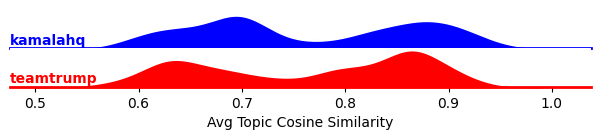

<Figure size 640x480 with 0 Axes>

In [96]:
palette = {'kamalahq': 'blue',
           'teamtrump': 'red'
           }
g = sns.FacetGrid(df, row="candidate", hue="candidate", aspect=15, height=.5, palette=palette)

# Draw the densities in a few steps
g.map(sns.kdeplot, "Avg Topic Cosine Similarity",
      bw_adjust=.5, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "Avg Topic Cosine Similarity", clip_on=False, color="w", lw=2, bw_adjust=.5)

# passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)

g.map(label, "Avg Topic Cosine Similarity")

g.figure.subplots_adjust(hspace=0)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

plt.show()
plt.savefig('drive/MyDrive/cosine_similarity_dist.png')

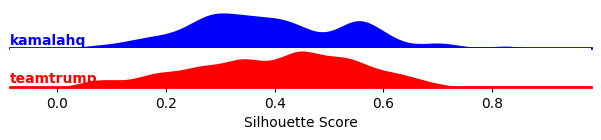

<Figure size 640x480 with 0 Axes>

In [97]:
g = sns.FacetGrid(df, row="candidate", hue="candidate", aspect=15, height=.5, palette=palette)

g.map(sns.kdeplot, "Silhouette Score",
      bw_adjust=.5, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "Silhouette Score", clip_on=False, color="w", lw=2, bw_adjust=.5)

g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

g.map(label, "Silhouette Score")

g.figure.subplots_adjust(hspace=0)

g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

plt.show()
plt.savefig('drive/MyDrive/silhouette_score_dist.png')

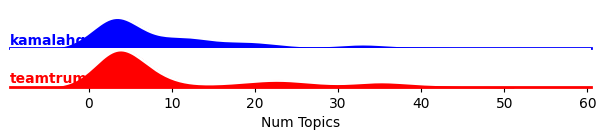

<Figure size 640x480 with 0 Axes>

In [133]:
g = sns.FacetGrid(df, row="candidate", hue="candidate", aspect=15, height=.5, palette=palette)

g.map(sns.kdeplot, "Num Topics",
      bw_adjust=.5, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "Num Topics", clip_on=False, color="w", lw=2, bw_adjust=.5)

g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

g.map(label, "Num Topics")

g.figure.subplots_adjust(hspace=0)

g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

plt.show()
plt.savefig('drive/MyDrive/num_topics_dist.png')

In [134]:
k_cosine = k_cv_df['Avg Topic Cosine Similarity'].to_list()
t_cosine = t_cv_df['Avg Topic Cosine Similarity'].to_list()
k_scores = k_cv_df['Silhouette Score'].to_list()
t_scores = t_cv_df['Silhouette Score'].to_list()
t_num_topics = t_cv_df['Num Topics'].to_list()
k_num_topics = k_cv_df['Num Topics'].to_list()

In [136]:
ttest_dict = {'Metric': ['Avg Topic Cosine Similarity', 'Silhouette Score', 'Number of Topics'],
              'Harris Mean': [round(np.mean(k_cosine), 3), round(np.mean(k_scores), 3), round(np.mean(k_num_topics), 2)],
              'Trump Mean': [round(np.mean(t_cosine), 3), round(np.mean(t_scores), 3), round(np.mean(t_num_topics), 2)],
              }

In [137]:
ttest_df = pd.DataFrame(ttest_dict)
ttest_df.to_csv('drive/MyDrive/topic_t_test.csv', index = False)

In [47]:
!pip install great_tables
!pip install selenium
from great_tables import GT

In [139]:
import pandas as pd
ttest_df = pd.read_csv('drive/MyDrive/topic_t_test.csv')

In [140]:
ttest_table = GT(ttest_df)
#ttest_table.save('drive/MyDrive/topic_t_test.png')


In [141]:
ttest_table

Metric,Harris Mean,Trump Mean
Avg Topic Cosine Similarity,0.764,0.765
Silhouette Score,0.399,0.399
Number of Topics,12.0,11.36


In [111]:
k_topic_info = kamalahq_topic.get_topic_info()
t_topic_info = teamtrump_topic.get_topic_info()

In [113]:
k_topic_info['Embedding'] = k_topic_info.apply(lambda x: kamalahq_topic.topic_embeddings_[x['Topic']+1], axis=1)
t_topic_info['Embedding'] = t_topic_info.apply(lambda x: teamtrump_topic.topic_embeddings_[x['Topic']+1], axis=1)

In [114]:
k_topic_info.to_csv('drive/MyDrive/kamalahq_topic_info.csv')
t_topic_info.to_csv('drive/MyDrive/teamtrump_topic_info.csv')

In [121]:
random.seed(42)
k_sample = embedding_model.encode(random.sample(kamalahq_text['video_description'].to_list(), 1000))
t_sample = embedding_model.encode(random.sample(teamtrump_text['video_description'].to_list(), 1000))

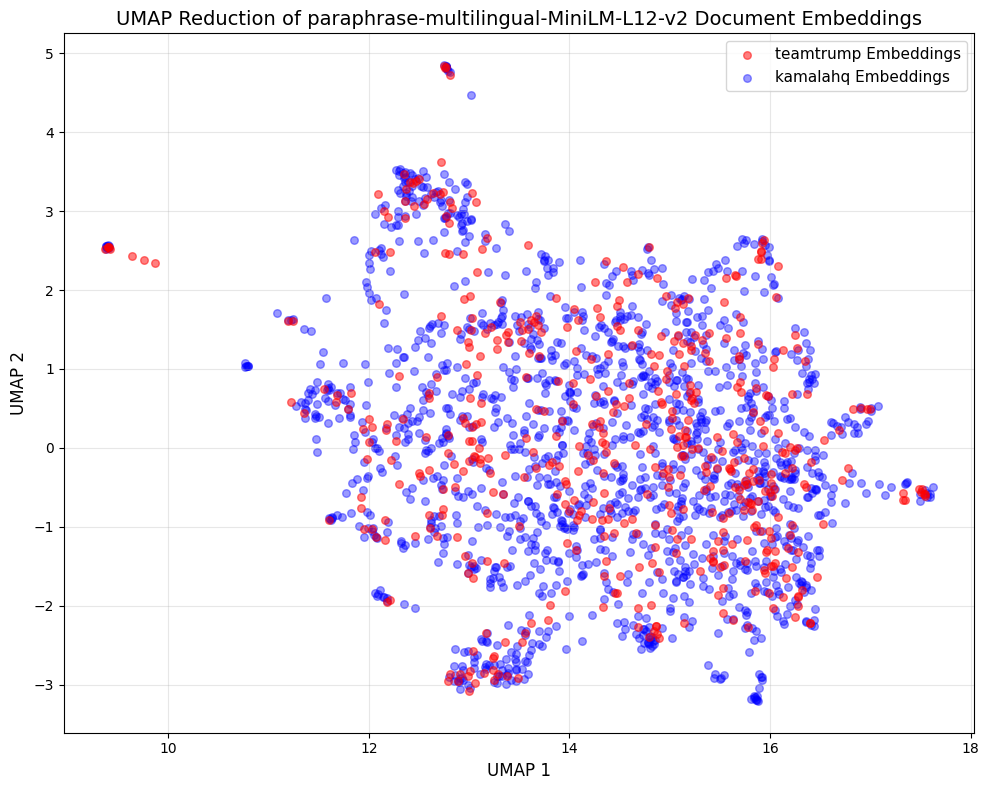

In [132]:
np.random.seed(42)

all_embeddings = np.vstack([
    np.array(t_sample.tolist()),
    np.array(k_sample.tolist())
])
reducer = UMAP(n_components=2, random_state=42)
reduced_embeddings = reducer.fit_transform(all_embeddings)

reduced_t = reduced_embeddings[:500]
reduced_k = reduced_embeddings[500:]

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(reduced_t[:, 0], reduced_t[:, 1], c='red', label='teamtrump Embeddings',
           alpha=0.5, s=30, #edgecolors='darkred', linewidth=1.2
           zorder=2
           )

ax.scatter(reduced_k[:, 0], reduced_k[:, 1], c='blue', label='kamalahq Embeddings',
           alpha=0.4, s=30, #edgecolors='darkblue', linewidth=1.2
           zorder=1
           )

ax.set_xlabel('UMAP 1', fontsize=12)
ax.set_ylabel('UMAP 2', fontsize=12)
ax.set_title('UMAP Reduction of paraphrase-multilingual-MiniLM-L12-v2 Document Embeddings', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('drive/MyDrive/topic_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
k_topic = pd.read_csv('drive/MyDrive/kamalahq_topic_info.csv')
t_topic = pd.read_csv('drive/MyDrive/teamtrump_topic_info.csv')

In [14]:
final_model = {'Metric': ['Number of Topics', 'Silhouette Score', 'Avg Pairwise Cosine Similarity'],
               'Harris': [str(29), 0.598, 0.641],
               'Trump': [str(23), 0.627, 0.662]
}
df_final = pd.DataFrame(final_model)

In [15]:
gt_final = GT(df_final).tab_header('Selected Topic Model Measures')

In [16]:
gt_final

GT(_tbl_data=                           Metric Harris  Trump
0                Number of Topics     29     23
1                Silhouette Score  0.598  0.627
2  Avg Pairwise Cosine Similarity  0.641  0.662, _body=<great_tables._gt_data.Body object at 0x79ac67d09760>, _boxhead=Boxhead([ColInfo(var='Metric', type=<ColInfoTypeEnum.default: 1>, column_label='Metric', column_align='left', column_width=None), ColInfo(var='Harris', type=<ColInfoTypeEnum.default: 1>, column_label='Harris', column_align='right', column_width=None), ColInfo(var='Trump', type=<ColInfoTypeEnum.default: 1>, column_label='Trump', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x79ac68476570>, _spanners=Spanners([]), _heading=Heading(title='Selected Topic Model Measures', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x79ac67d0a9f0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x79ac67d0abd0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x79ac67d0a990>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), heading_background_color=OptionsInfo(scss=True, category='heading', type='value', value=None), heading_align=OptionsInfo(scss=Tru